# Route 208 — Battery Electric Bus Energy & Loading Analysis

Segment → trip → duty energy consumption and passenger-loading analysis for the
simulated BEB operation of route **208 (Lotabeg  -  Bishopstown  -  Curraheen)**.

The data is one simulated service day (`2025-01-06`) covering two service variants,
16 vehicle blocks, 32 duties, 412 trips and ~15.1k stop-to-stop segments. The
pipeline writes per-segment energy (`energy_kWh`), specific consumption
(`kWh_per_km`), grade, passenger load and a continuous state-of-charge that carries
across trips within a duty.

**Structure**
1. Setup, load, derived fields
2. Data overview & sanity checks (incl. implied pack capacity)
3. Segment-level energy analysis
4. Trip-level energy analysis
5. Duty-level energy & SoC-trajectory analysis
6. Passenger-loading analysis
7. Synthesis

## 1 · Setup, load & derived fields

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import PercentFormatter
import seaborn as sns

# ----- a cohesive visual theme used across every figure -----------------------
INK   = "#1f2433"   # text / spines
OUT   = "#2a9d8f"   # direction 0  (outbound)
IN    = "#e76f51"   # direction 1  (inbound)
ACC   = "#3d5a80"   # single-series primary
ACC2  = "#ee9b00"   # secondary accent
REGEN = "#52b788"   # regeneration
GRID  = "#dde1e7"
DIRCOLORS = {0: OUT, 1: IN}
SEQ = "mako"        # sequential colormap for heatmaps

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK, "ytick.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 10,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "legend.frameon": False,
})

def titled(ax, title, subtitle=None):
    """Bold title with an optional muted subtitle line beneath it."""
    ax.set_title(title, loc="left", pad=24 if subtitle else 10)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes,
                fontsize=9.5, color="#6b7280", ha="left", va="bottom")
    return ax

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

In [3]:
df = pd.read_csv("../data/processed/route_208_trips.csv")

# --- derived fields ----------------------------------------------------------
df["dist_km"]   = df["length_m"] / 1000.0
df["speed_kmh"] = df["length_m"] / df["run_time_s"] * 3.6        # in-motion avg speed
df["is_regen"]  = df["energy_kWh"] < 0
df["dir_label"] = df["direction_id"].map({0: "Outbound", 1: "Inbound"})

# clock / time-of-day from each trip's scheduled departure
df["dep_dt"]   = pd.to_datetime(df["trip_start_time"], format="%H:%M:%S")
df["dep_hour"] = df["dep_dt"].dt.hour

def tod(h):
    if h < 7:   return "Early (<07)"
    if h <= 9:  return "AM peak (07 - 09)"
    if h <= 15: return "Midday (10 - 15)"
    if h <= 18: return "PM peak (16 - 18)"
    return "Evening (19+)"
TOD_ORDER = ["Early (<07)", "AM peak (07 - 09)", "Midday (10 - 15)",
             "PM peak (16 - 18)", "Evening (19+)"]
df["period"] = pd.Categorical(df["dep_hour"].map(tod), TOD_ORDER, ordered=True)

# a real timeline for SoC plots. GTFS times can exceed 24:00:00 for post-midnight
# service, so parse as seconds-since-midnight offsets from the simulated date.
def gtfs_seconds(s):
    parts = s.str.split(":", expand=True).astype(int)
    return parts[0] * 3600 + parts[1] * 60 + parts[2]
df["seg_arr_dt"] = (pd.to_datetime(df["simulation_date"])
                    + pd.to_timedelta(gtfs_seconds(df["to_stop_arrival_time"]), unit="s"))

print(f"{len(df):,} segments | {df.trip_id.nunique()} trips | "
      f"{df.duty_id.nunique()} duties | {df.block_id.nunique()} blocks")
df.head(3)

15,122 segments | 412 trips | 32 duties | 16 blocks


,route_short_name,route_long_name,route_id,service_id,block_id,duty_id,duty_index,duty_trip_index,duty_trip_count,duty_start_time,direction_id,trip_id,simulation_date,trip_start_time,trip_start_soc_%,segment,from_stop_departure_time,to_stop_arrival_time,to_stop_departure_time,run_time_s,dwell_s,length_m,grade_%,passengers,energy_kWh,kWh_per_km,cum_dist_km,SoC_start_%,SoC_end_%,trip_end_soc_%,dist_km,speed_kmh,is_regen,dir_label,dep_dt,dep_hour,period,seg_arr_dt
0,208,Lotabeg - Bishopstown - Curraheen,2 208 c a,226,5695_7778208_42080203,226:5695_7778208_42080203,0,0,21,06:30:00,0,5695_40633,2025-01-06,06:30:00,100.0,0,06:30:00,06:31:00,06:31:00,60,0,215.9,-0.46,0,0.141,0.652,0.216,100.00,99.97,97.46,0.2159,12.954,False,Outbound,1900-01-01 06:30:00,6,Early (<07),2025-01-06 06:31:00
1,208,Lotabeg - Bishopstown - Curraheen,2 208 c a,226,5695_7778208_42080203,226:5695_7778208_42080203,0,0,21,06:30:00,0,5695_40633,2025-01-06,06:30:00,100.0,1,06:31:00,06:33:30,06:33:30,150,0,446.0,-0.67,0,0.249,0.558,0.662,99.97,99.90,97.46,0.4460,10.704,False,Outbound,1900-01-01 06:30:00,6,Early (<07),2025-01-06 06:33:30
2,208,Lotabeg - Bishopstown - Curraheen,2 208 c a,226,5695_7778208_42080203,226:5695_7778208_42080203,0,0,21,06:30:00,0,5695_40633,2025-01-06,06:30:00,100.0,2,06:33:30,06:34:30,06:34:30,60,0,394.5,-0.25,2,0.288,0.729,1.056,99.90,99.83,97.46,0.3945,23.670,False,Outbound,1900-01-01 06:30:00,6,Early (<07),2025-01-06 06:34:30


## 2 · Data overview & sanity checks

Before analysis, confirm the hierarchy and back out the battery pack capacity the
simulator implied (energy drawn per percent of SoC consumed). A tight spread here
is a good integrity check on the SoC bookkeeping.

In [ ]:
# derive pack capacity per duty: total energy / total SoC drop across its trips
cap_rows = []
for did, g in df.groupby("duty_id"):
    tr = g.groupby("duty_trip_index").agg(e=("energy_kWh", "sum"),
                                          s0=("trip_start_soc_%", "first"),
                                          s1=("trip_end_soc_%", "first"))
    drop = (tr.s0 - tr.s1).sum()
    if drop > 0:
        cap_rows.append(tr.e.sum() / (drop / 100.0))
cap = np.array(cap_rows)
BATTERY_KWH = float(np.median(cap))

overview = pd.Series({
    "Route":                  f"208 — {df.route_long_name.iloc[0]}",
    "Simulated date":         df.simulation_date.iloc[0],
    "Service variants":       ", ".join(map(str, sorted(df.service_id.unique()))),
    "Blocks / duties / trips": f"{df.block_id.nunique()} / {df.duty_id.nunique()} / {df.trip_id.nunique()}",
    "Segments":               f"{len(df):,}",
    "Total distance (km)":    f"{df.dist_km.sum():,.0f}",
    "Total energy (kWh)":     f"{df.energy_kWh.sum():,.0f}",
    "Fleet mean (kWh/km)":    f"{df.energy_kWh.sum()/df.dist_km.sum():.3f}",
    "Regen segments":         f"{df.is_regen.mean()*100:.1f}%",
    "Implied pack (kWh)":     f"{BATTERY_KWH:.0f}  (spread {cap.min():.1f} - {cap.max():.1f})",
}, name="value")
print(overview.to_string())

Route                      208 — Lotabeg - Bishopstown - Curraheen
Simulated date                                          2025-01-06
Service variants                                          226, 242
Blocks / duties / trips                              16 / 32 / 412
Segments                                                    15,122
Total distance (km)                                          4,527
Total energy (kWh)                                           7,211
Fleet mean (kWh/km)                                          1.593
Regen segments                                               16.0%
Implied pack (kWh)                       410  (spread 409.8–410.3)


In [4]:
# missing-value & range check
chk = pd.DataFrame({
    "nulls": df.isna().sum(),
}).query("nulls > 0")
print("Columns with nulls:", "none" if chk.empty else "")
if not chk.empty:
    print(chk)

num = ["run_time_s","dwell_s","dist_km","speed_kmh","grade_%","passengers",
       "energy_kWh","kWh_per_km"]
df[num].describe().T[["mean","std","min","25%","50%","75%","max"]].round(3)

Columns with nulls: none


,mean,std,min,25%,50%,75%,max
run_time_s,67.662,51.631,30.000,30.000,60.000,60.000,300.000
dwell_s,8.558,55.369,0.000,0.000,0.000,0.000,570.000
dist_km,0.299,0.098,0.147,0.230,0.283,0.362,0.718
speed_kmh,20.924,10.287,2.033,13.830,17.796,26.280,54.120
grade_%,-0.173,3.225,-8.530,-1.820,0.000,1.250,7.420
passengers,30.660,23.964,0.000,8.000,28.000,51.000,85.000
energy_kWh,0.477,0.495,-0.242,0.135,0.347,0.747,2.758
kWh_per_km,1.560,1.511,-1.005,0.618,1.203,2.495,6.225


## 3 · Segment-level energy analysis

The stop-to-stop segment is the model's atomic unit. We look at the distribution of
per-segment energy and specific consumption, the prevalence of regeneration, and the
three physical drivers the quasi-static model is sensitive to: **grade, speed and
passenger mass**. A descriptive least-squares decomposition closes the section.

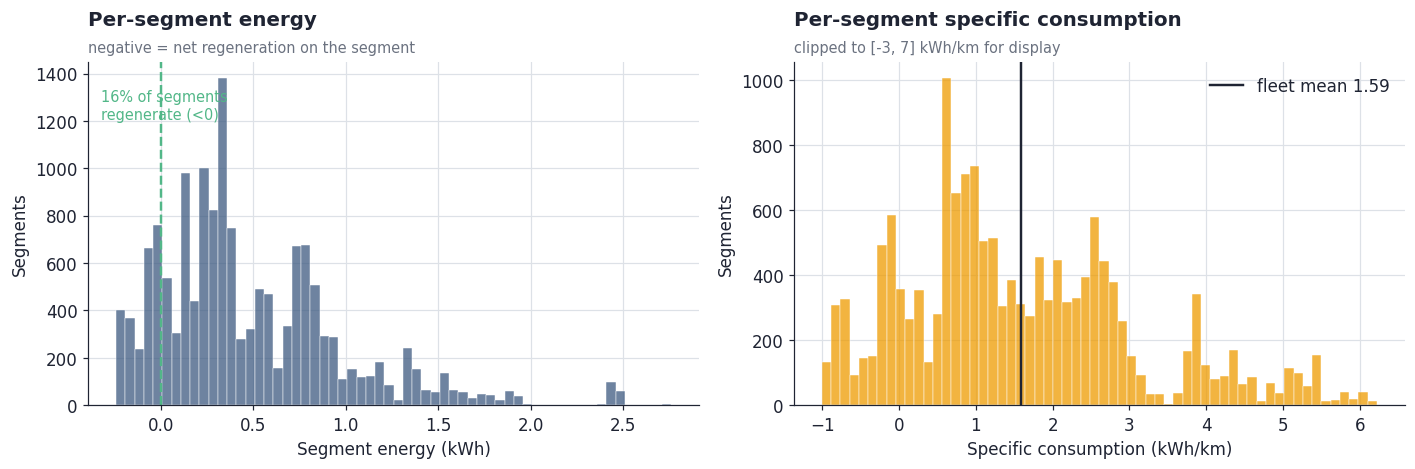

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
sns.histplot(df.energy_kWh, bins=60, color=ACC, edgecolor="white", linewidth=.3, ax=ax)
ax.axvline(0, color=REGEN, lw=1.6, ls="--")
ax.text(0.02, 0.92, f"{df.is_regen.mean()*100:.0f}% of segments\nregenerate (<0)",
        transform=ax.transAxes, color=REGEN, fontsize=9.5, va="top")
ax.set_xlabel("Segment energy (kWh)"); ax.set_ylabel("Segments")
titled(ax, "Per-segment energy", "negative = net regeneration on the segment")

ax = axes[1]
m = df.kWh_per_km.between(-3, 7)
sns.histplot(df.loc[m, "kWh_per_km"], bins=60, color=ACC2, edgecolor="white",
             linewidth=.3, ax=ax)
ax.axvline(df.energy_kWh.sum()/df.dist_km.sum(), color=INK, lw=1.6,
           label=f"fleet mean {df.energy_kWh.sum()/df.dist_km.sum():.2f}")
ax.set_xlabel("Specific consumption (kWh/km)"); ax.set_ylabel("Segments")
ax.legend(loc="upper right")
titled(ax, "Per-segment specific consumption", "clipped to [-3, 7] kWh/km for display")
plt.tight_layout(); plt.show()

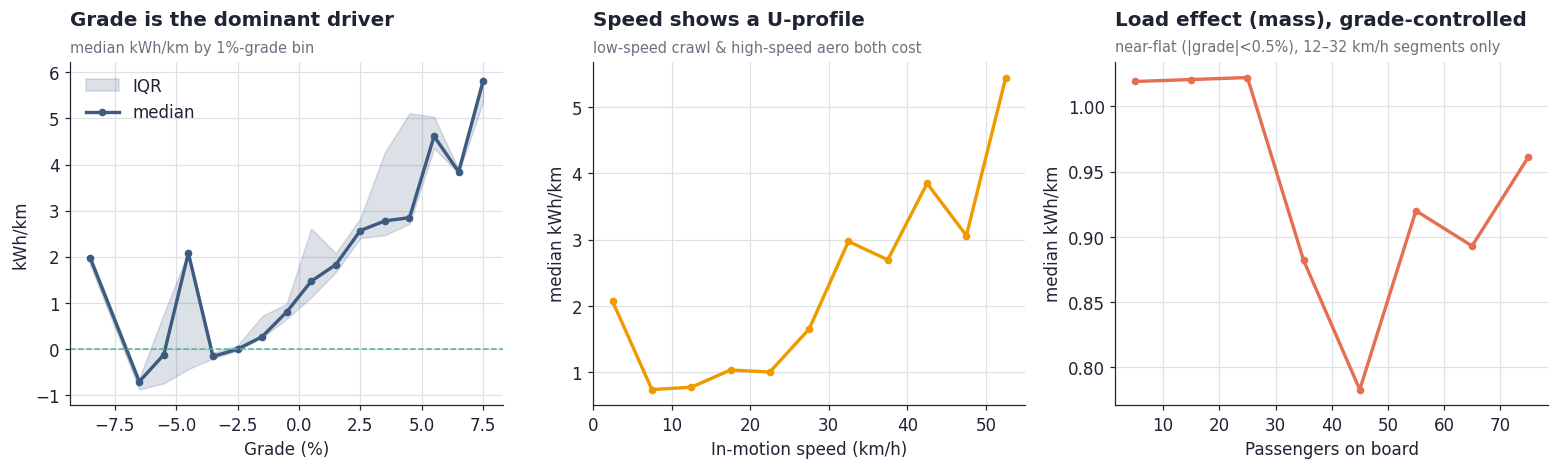

In [ ]:
# Driver 1 — grade. Bin grade and show median kWh/km with IQR band.
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4), sharey=False)

d = df[df.kWh_per_km.between(-4, 8)].copy()
d["grade_bin"] = pd.cut(d["grade_%"], np.arange(-9, 9, 1))
gb = d.groupby("grade_bin", observed=True)["kWh_per_km"].agg(["median","count",
        lambda s: s.quantile(.25), lambda s: s.quantile(.75)])
gb.columns = ["median","n","q1","q3"]
x = [iv.mid for iv in gb.index]
ax = axes[0]
ax.fill_between(x, gb.q1, gb.q3, color=ACC, alpha=.18, label="IQR")
ax.plot(x, gb["median"], color=ACC, lw=2.2, marker="o", ms=4, label="median")
ax.axhline(0, color=REGEN, lw=1, ls="--")
ax.set_xlabel("Grade (%)"); ax.set_ylabel("kWh/km")
ax.legend(loc="upper left")
titled(ax, "Grade is the dominant driver", "median kWh/km by 1%-grade bin")

# Driver 2 — speed (U-shape: idle/HVAC at low speed, aero at high speed)
d["spd_bin"] = pd.cut(d["speed_kmh"], np.arange(0, 60, 5))
sb = d.groupby("spd_bin", observed=True)["kWh_per_km"].median()
ax = axes[1]
ax.plot([iv.mid for iv in sb.index], sb.values, color=ACC2, lw=2.2, marker="o", ms=4)
ax.set_xlabel("In-motion speed (km/h)"); ax.set_ylabel("median kWh/km")
titled(ax, "Speed shows a U-profile", "low-speed crawl & high-speed aero both cost")

# Driver 3 — passenger load (mass), on near-flat segments to isolate it
flat = d[(d["grade_%"].abs() < 0.5) & d["speed_kmh"].between(12, 32)].copy()
flat["pax_bin"] = pd.cut(flat["passengers"], np.arange(0, 90, 10))
pb = flat.groupby("pax_bin", observed=True)["kWh_per_km"].median()
ax = axes[2]
ax.plot([iv.mid for iv in pb.index], pb.values, color=IN, lw=2.2, marker="o", ms=4)
ax.set_xlabel("Passengers on board"); ax.set_ylabel("median kWh/km")
titled(ax, "Load effect (mass), grade-controlled",
       "near-flat (|grade|<0.5%), 12 - 32 km/h segments only")
plt.tight_layout(); plt.show()

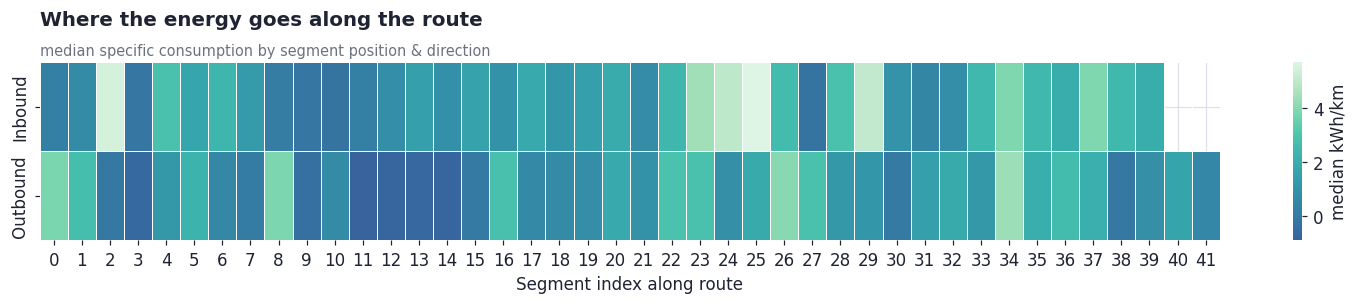

In [7]:
# Energy intensity along the route — segment position x direction
heat = (df.pivot_table(index="dir_label", columns="segment",
                       values="kWh_per_km", aggfunc="median"))
fig, ax = plt.subplots(figsize=(14, 2.9))
sns.heatmap(heat, cmap=SEQ, center=0, linewidths=.4, linecolor="white",
            cbar_kws={"label": "median kWh/km"}, ax=ax)
ax.set_xlabel("Segment index along route"); ax.set_ylabel("")
titled(ax, "Where the energy goes along the route",
       "median specific consumption by segment position & direction")
plt.tight_layout(); plt.show()

In [8]:
# Descriptive least-squares decomposition of segment energy.
# energy ≈ β0 + β1·dist + β2·(grade·dist) + β3·(pax·dist) + β4·(dist/speed)
# Interpretable, NOT causal — collinearity between terms is real; read as bookkeeping.
sub = df[(df.run_time_s > 0) & df.speed_kmh.between(2, 60)].copy()
X = pd.DataFrame({
    "intercept":  1.0,
    "dist_km":    sub.dist_km,
    "grade·dist": sub["grade_%"] * sub.dist_km,
    "pax·dist":   sub.passengers * sub.dist_km,
    "time(dist/spd)": sub.dist_km / sub.speed_kmh,
})
y = sub.energy_kWh.values
beta, *_ = np.linalg.lstsq(X.values, y, rcond=None)
yhat = X.values @ beta
ss_res = ((y - yhat) ** 2).sum(); ss_tot = ((y - y.mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot

coef = pd.Series(beta, index=X.columns).round(4)
print("Descriptive decomposition of segment energy (kWh)")
print("-" * 48)
print(coef.to_string())
print("-" * 48)
print(f"R² = {r2:.3f}   n = {len(sub):,}")
print("\nReading: ~", round(coef['dist_km'],2), "kWh/km baseline rolling+aux;",
      "+", round(coef['grade·dist'],3), "kWh per km per +1% grade;",
      "+", round(coef['pax·dist']*10,3), "kWh per km per +10 pax.")

Descriptive decomposition of segment energy (kWh)
------------------------------------------------
intercept         0.1884
dist_km           1.5350
grade·dist        0.3928
pax·dist         -0.0088
time(dist/spd)   -4.8471
------------------------------------------------
R² = 0.659   n = 15,122

Reading: ~ 1.54 kWh/km baseline rolling+aux; + 0.393 kWh per km per +1% grade; + -0.088 kWh per km per +10 pax.


## 4 · Trip-level energy analysis

Rolling segments up to whole trips (one end-to-end run). We compare directions —
which differ in net grade — and trace the time-of-day signature that passenger
loading imprints on consumption.

In [9]:
trips = (df.groupby("trip_id")
    .agg(duty_id=("duty_id","first"), direction=("direction_id","first"),
         dir_label=("dir_label","first"), period=("period","first"),
         dep_hour=("dep_hour","first"), dep_time=("trip_start_time","first"),
         segs=("segment","count"), dist_km=("dist_km","sum"),
         dur_min=("run_time_s", lambda s: (s.sum()+0)/60),
         energy_kWh=("energy_kWh","sum"), pax_mean=("passengers","mean"),
         pax_max=("passengers","max"),
         soc0=("trip_start_soc_%","first"), soc1=("trip_end_soc_%","first"))
    .reset_index())
trips["kWh_per_km"] = trips.energy_kWh / trips.dist_km
trips["soc_drop"]   = trips.soc0 - trips.soc1
trips["dur_min"]    = (df.groupby("trip_id")["run_time_s"].sum()
                       + df.groupby("trip_id")["dwell_s"].sum()).values / 60
print(f"{len(trips)} trips")
trips[["dist_km","dur_min","energy_kWh","kWh_per_km","pax_mean","soc_drop"]]     .describe().loc[["mean","std","min","50%","max"]].round(2)

412 trips


,dist_km,dur_min,energy_kWh,kWh_per_km,pax_mean,soc_drop
mean,10.99,46.63,17.50,1.59,30.10,4.27
std,1.35,8.41,3.89,0.29,11.32,0.95
min,4.71,13.00,3.84,0.82,0.00,0.94
50%,11.17,48.50,16.79,1.52,31.76,4.09
max,13.13,60.50,23.52,2.05,47.10,5.74


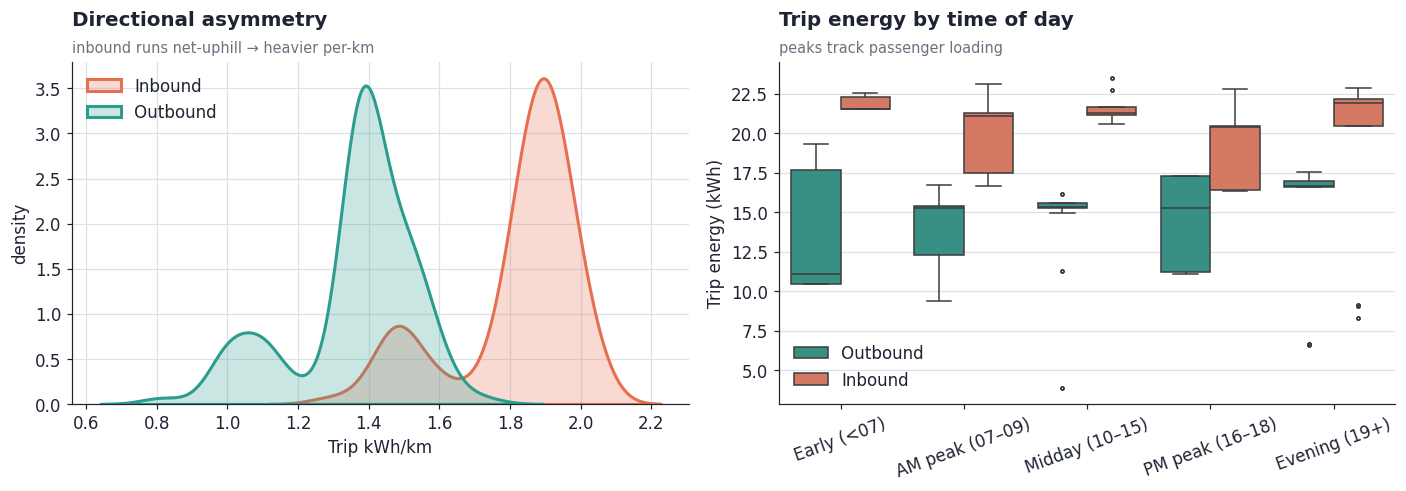

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
for dlab, g in trips.groupby("dir_label"):
    sns.kdeplot(g.kWh_per_km, ax=ax, fill=True, alpha=.25,
                color=DIRCOLORS[0 if dlab=="Outbound" else 1], label=dlab, lw=2)
ax.set_xlabel("Trip kWh/km"); ax.set_ylabel("density")
ax.legend(title="")
titled(ax, "Directional asymmetry", "inbound runs net-uphill → heavier per-km")

ax = axes[1]
sns.boxplot(data=trips, x="period", y="energy_kWh", hue="dir_label",
            palette=[OUT, IN], ax=ax, fliersize=2, linewidth=1)
ax.set_xlabel(""); ax.set_ylabel("Trip energy (kWh)")
ax.tick_params(axis="x", rotation=20); ax.legend(title="")
titled(ax, "Trip energy by time of day", "peaks track passenger loading")
plt.tight_layout(); plt.show()

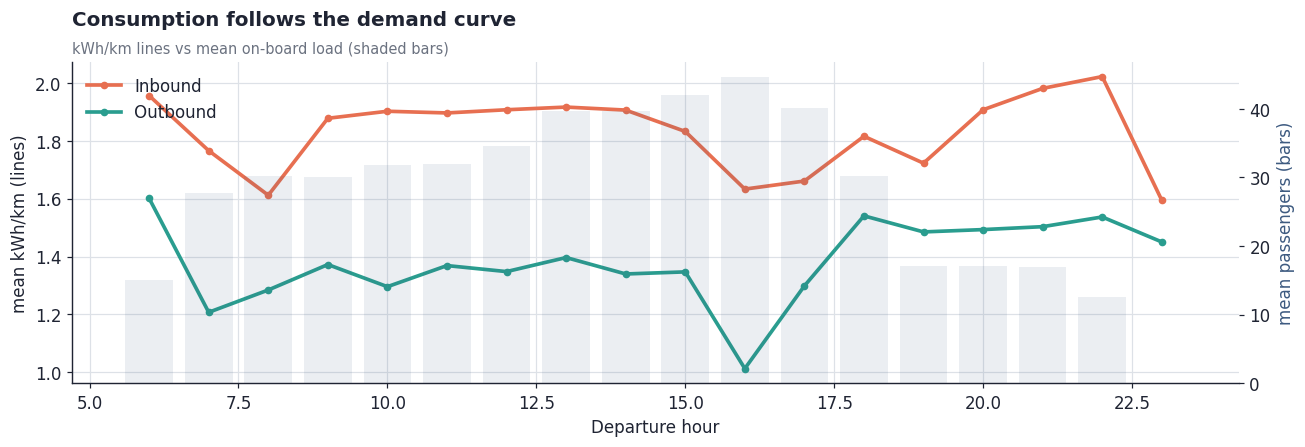

In [11]:
# Time-of-day consumption profile (mean kWh/km by departure hour, per direction)
prof = (trips.groupby(["dep_hour","dir_label"])
        .agg(kwh_km=("kWh_per_km","mean"), pax=("pax_mean","mean")).reset_index())
fig, ax = plt.subplots(figsize=(12, 4.2))
ax2 = ax.twinx(); ax2.grid(False)
for dlab, g in prof.groupby("dir_label"):
    c = DIRCOLORS[0 if dlab=="Outbound" else 1]
    ax.plot(g.dep_hour, g.kwh_km, color=c, lw=2.4, marker="o", ms=4, label=dlab)
pax_all = trips.groupby("dep_hour")["pax_mean"].mean()
ax2.bar(pax_all.index, pax_all.values, color=ACC, alpha=.10, width=.8, zorder=0)
ax2.set_ylabel("mean passengers (bars)", color=ACC)
ax.set_xlabel("Departure hour"); ax.set_ylabel("mean kWh/km (lines)")
ax.legend(loc="upper left")
titled(ax, "Consumption follows the demand curve",
       "kWh/km lines vs mean on-board load (shaded bars)")
plt.tight_layout(); plt.show()

## 5 · Duty-level energy & state-of-charge

A **duty** is a full vehicle assignment for the day. This is the operationally decisive
level: it determines whether a vehicle completes its schedule on one charge and how much
reserve is left — directly feeding charging-infrastructure placement. The SoC trajectory
plot is the headline.

In [12]:
duties = (df.groupby("duty_id")
    .agg(service=("service_id","first"),
         trips=("duty_trip_index","nunique"),
         segs=("segment","count"), dist_km=("dist_km","sum"),
         energy_kWh=("energy_kWh","sum"),
         start=("trip_start_time","min"),
         pax_mean=("passengers","mean"),
         soc_end=("SoC_end_%","last"))
    .reset_index())
# min SoC actually reached anywhere in the duty (continuous within-duty SoC)
minsoc = (df.sort_values(["duty_id","duty_trip_index","segment"])
            .groupby("duty_id")["SoC_end_%"].min())
duties["soc_min"] = duties.duty_id.map(minsoc).values
duties["energy_per_km"] = duties.energy_kWh / duties.dist_km
duties = duties.sort_values("energy_kWh", ascending=False).reset_index(drop=True)
print(f"{len(duties)} duties | mean {duties.energy_kWh.mean():.0f} kWh "
      f"({duties.energy_kWh.mean()/BATTERY_KWH*100:.0f}% of pack) | "
      f"lowest end-SoC {duties.soc_min.min():.1f}%")
duties.head(8).round(2)

32 duties | mean 225 kWh (55% of pack) | lowest end-SoC 10.8%


,duty_id,service,trips,segs,dist_km,energy_kWh,start,pax_mean,soc_end,soc_min,energy_per_km
0,226:5695_7778208_42080203,226,21,750,223.20,365.61,06:30:00,27.06,10.83,10.83,1.64
1,242:5695_7778208_42080203,242,21,750,223.20,365.61,06:30:00,27.06,10.83,10.83,1.64
2,242:5695_7778208_42080205,242,20,729,216.75,350.77,06:50:00,27.51,14.44,14.44,1.62
3,226:5695_7778208_42080205,226,20,729,216.75,350.77,06:50:00,27.51,14.44,14.44,1.62
4,226:5695_7778208_42080207,226,19,720,215.81,348.31,06:55:00,28.40,15.05,15.05,1.61
5,242:5695_7778208_42080207,242,19,720,215.81,348.31,06:55:00,28.40,15.05,15.05,1.61
6,242:5695_7778208_42080206,242,20,724,217.54,347.60,06:40:00,27.82,15.24,15.24,1.60
7,226:5695_7778208_42080206,226,20,724,217.54,347.60,06:40:00,27.82,15.24,15.24,1.60


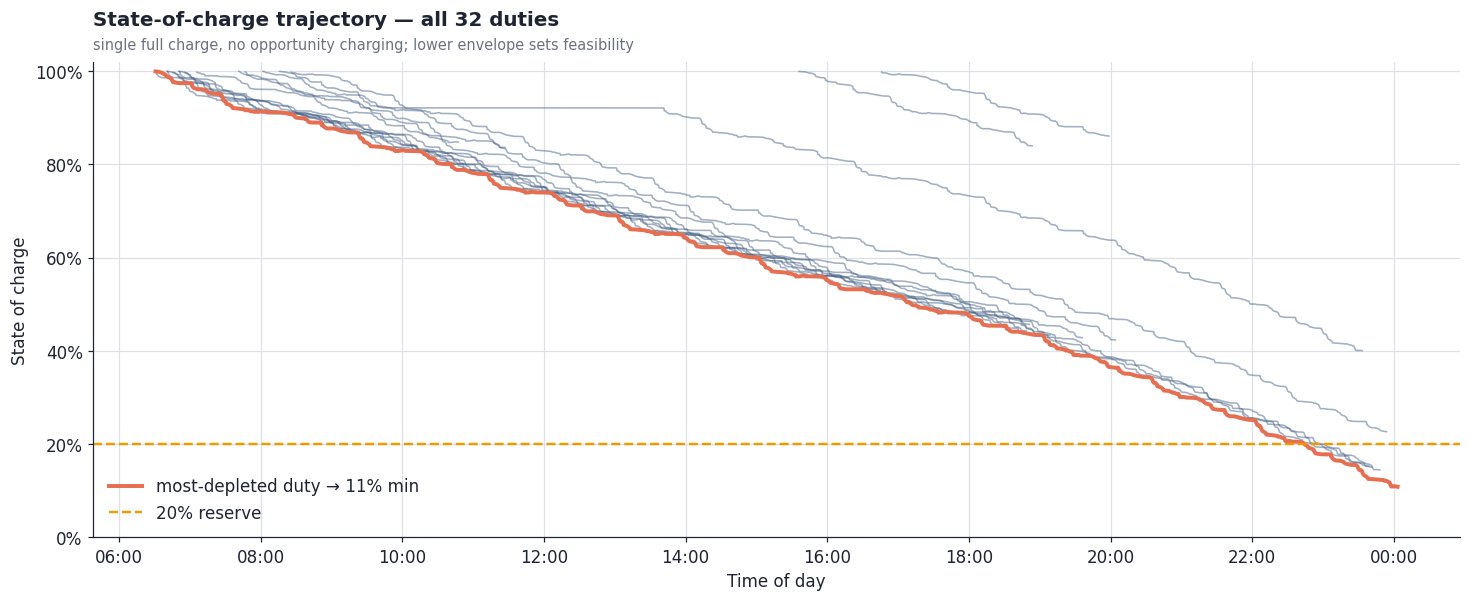

In [13]:
# Headline: SoC trajectory across the day for every duty
RESERVE = 20  # % operational reserve line
fig, ax = plt.subplots(figsize=(13.5, 5.6))
order = df.sort_values(["duty_id","duty_trip_index","segment"])
for did, g in order.groupby("duty_id"):
    ax.plot(g.seg_arr_dt, g["SoC_end_%"], color=ACC, alpha=.28, lw=1)
# highlight the single most-depleted duty
worst = duties.loc[duties.soc_min.idxmin()]
gw = order[order.duty_id == worst.duty_id]
ax.plot(gw.seg_arr_dt, gw["SoC_end_%"], color=IN, lw=2.6,
        label=f"most-depleted duty → {worst.soc_min:.0f}% min")
ax.axhline(RESERVE, color=ACC2, ls="--", lw=1.6, label=f"{RESERVE}% reserve")
ax.set_ylim(0, 102); ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_xlabel("Time of day"); ax.set_ylabel("State of charge")
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend(loc="lower left")
titled(ax, "State-of-charge trajectory — all 32 duties",
       "single full charge, no opportunity charging; lower envelope sets feasibility")
plt.tight_layout(); plt.show()

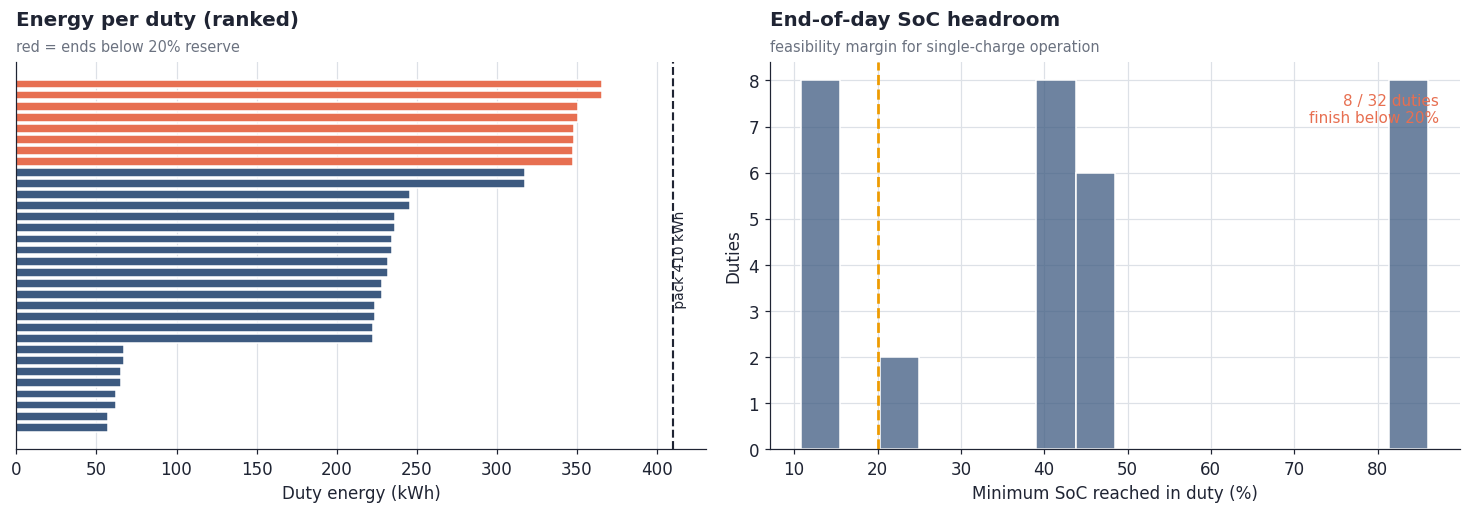

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

ax = axes[0]
colors = [IN if v < RESERVE else ACC for v in duties.soc_min]
ax.barh(range(len(duties)), duties.energy_kWh, color=colors, edgecolor="white")
ax.invert_yaxis(); ax.set_yticks([])
ax.axvline(BATTERY_KWH, color=INK, ls="--", lw=1.4)
ax.text(BATTERY_KWH, len(duties)*.5, f" pack {BATTERY_KWH:.0f} kWh",
        rotation=90, va="center", fontsize=9, color=INK)
ax.set_xlabel("Duty energy (kWh)")
titled(ax, "Energy per duty (ranked)",
       "red = ends below 20% reserve")

ax = axes[1]
sns.histplot(duties.soc_min, bins=16, color=ACC, edgecolor="white", ax=ax)
ax.axvline(RESERVE, color=ACC2, ls="--", lw=1.8)
n_risk = (duties.soc_min < RESERVE).sum()
ax.text(.97, .92, f"{n_risk} / {len(duties)} duties\nfinish below {RESERVE}%",
        transform=ax.transAxes, ha="right", va="top", color=IN, fontsize=10)
ax.set_xlabel("Minimum SoC reached in duty (%)"); ax.set_ylabel("Duties")
titled(ax, "End-of-day SoC headroom",
       "feasibility margin for single-charge operation")
plt.tight_layout(); plt.show()

## 6 · Passenger-loading analysis

The boarding profile shapes both crowding and the mass term in consumption. We look at
the load shape along the route, how demand moves through the day, and re-confirm the
energy cost of carrying passengers with grade and speed held in a narrow band.

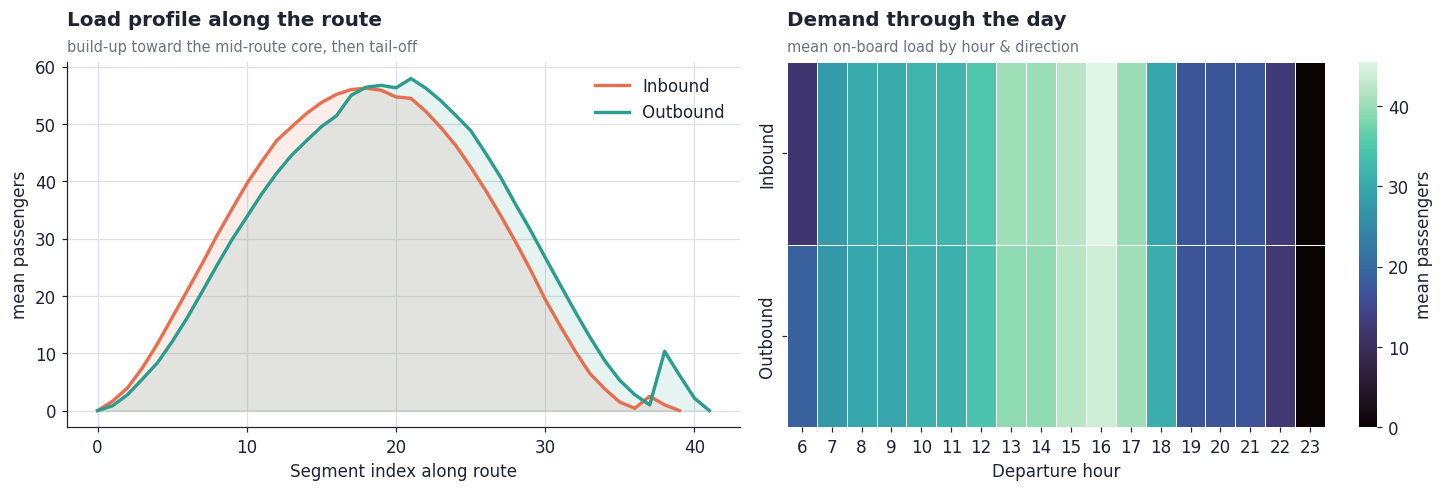

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

# load shape along the route by direction
ax = axes[0]
ls = df.groupby(["segment","dir_label"])["passengers"].mean().reset_index()
for dlab, g in ls.groupby("dir_label"):
    c = DIRCOLORS[0 if dlab=="Outbound" else 1]
    ax.plot(g.segment, g.passengers, color=c, lw=2.2, label=dlab)
    ax.fill_between(g.segment, g.passengers, color=c, alpha=.12)
ax.set_xlabel("Segment index along route"); ax.set_ylabel("mean passengers")
ax.legend(title="")
titled(ax, "Load profile along the route",
       "build-up toward the mid-route core, then tail-off")

# demand through the day x direction
ax = axes[1]
hd = df.pivot_table(index="dir_label", columns="dep_hour",
                    values="passengers", aggfunc="mean")
sns.heatmap(hd, cmap=SEQ, linewidths=.4, linecolor="white",
            cbar_kws={"label": "mean passengers"}, ax=ax)
ax.set_xlabel("Departure hour"); ax.set_ylabel("")
titled(ax, "Demand through the day", "mean on-board load by hour & direction")
plt.tight_layout(); plt.show()

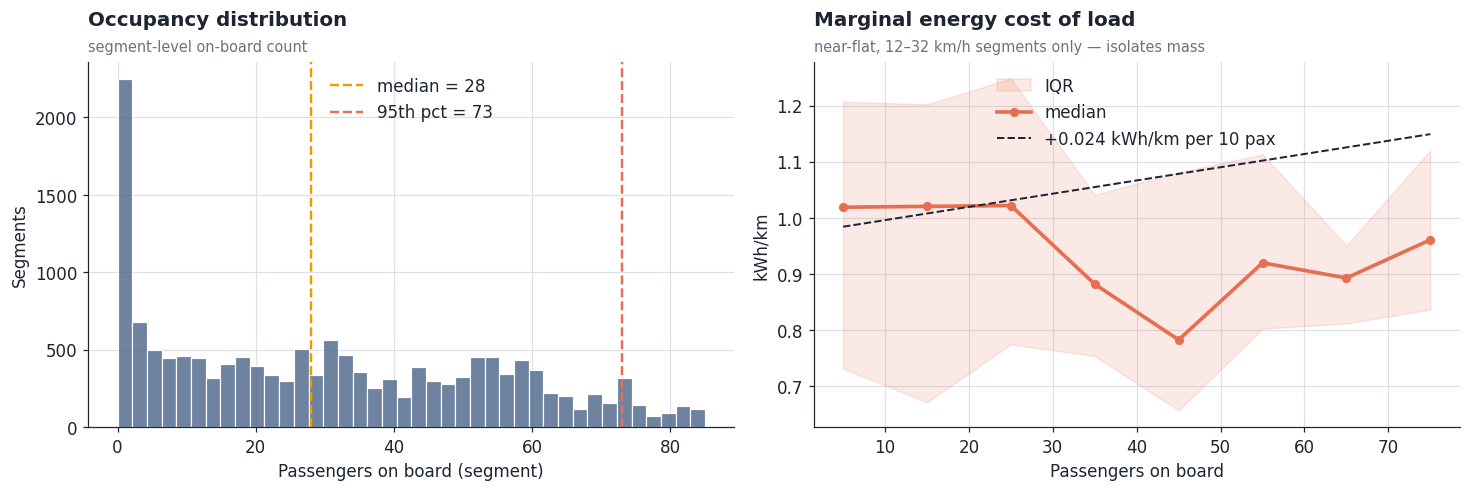

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

# occupancy distribution
ax = axes[0]
sns.histplot(df.passengers, bins=40, color=ACC, edgecolor="white", ax=ax)
for q, lab in [(.5,"median"), (.95,"95th pct")]:
    v = df.passengers.quantile(q)
    ax.axvline(v, color=ACC2 if q==.5 else IN, lw=1.6, ls="--",
               label=f"{lab} = {v:.0f}")
ax.set_xlabel("Passengers on board (segment)"); ax.set_ylabel("Segments")
ax.legend()
titled(ax, "Occupancy distribution", "segment-level on-board count")

# energy cost of load, grade- & speed-controlled, with bootstrap-free IQR band
ax = axes[1]
flat = df[(df["grade_%"].abs() < 0.5) & df.speed_kmh.between(12, 32)].copy()
flat["pax_bin"] = pd.cut(flat.passengers, np.arange(0, 90, 10))
agg = flat.groupby("pax_bin", observed=True)["kWh_per_km"].agg(
        median="median", q1=lambda s: s.quantile(.25),
        q3=lambda s: s.quantile(.75), n="count")
xm = [iv.mid for iv in agg.index]
ax.fill_between(xm, agg.q1, agg.q3, color=IN, alpha=.15, label="IQR")
ax.plot(xm, agg["median"], color=IN, lw=2.4, marker="o", ms=5, label="median")
# fit a simple slope for the headline number
sl, ic = np.polyfit(flat.passengers, flat.kWh_per_km, 1)
ax.plot(xm, ic + sl*np.array(xm), color=INK, lw=1.3, ls="--",
        label=f"+{sl*10:.3f} kWh/km per 10 pax")
ax.set_xlabel("Passengers on board"); ax.set_ylabel("kWh/km")
ax.legend()
titled(ax, "Marginal energy cost of load",
       "near-flat, 12–32 km/h segments only — isolates mass")
plt.tight_layout(); plt.show()

## 7 · Synthesis

In [17]:
flat_all = df[(df["grade_%"].abs() < 0.5) & df.speed_kmh.between(12, 32)]
pax_slope = np.polyfit(flat_all.passengers, flat_all.kWh_per_km, 1)[0]

summary = pd.Series({
    "Fleet mean consumption":     f"{df.energy_kWh.sum()/df.dist_km.sum():.2f} kWh/km",
    "Implied pack capacity":      f"{BATTERY_KWH:.0f} kWh",
    "Mean energy per duty":       f"{duties.energy_kWh.mean():.0f} kWh "
                                  f"({duties.energy_kWh.mean()/BATTERY_KWH*100:.0f}% of pack)",
    "Heaviest duty":              f"{duties.energy_kWh.max():.0f} kWh "
                                  f"({duties.energy_kWh.max()/BATTERY_KWH*100:.0f}% of pack)",
    "Lowest SoC reached":         f"{duties.soc_min.min():.1f}%",
    "Duties below 20% reserve":   f"{(duties.soc_min<20).sum()} of {len(duties)}",
    "Regenerating segments":      f"{df.is_regen.mean()*100:.1f}%",
    "Marginal load cost":         f"+{pax_slope*10:.3f} kWh/km per 10 passengers",
    "Inbound vs outbound kWh/km": f"{trips[trips.direction==1].kWh_per_km.mean():.2f}"
                                  f" vs {trips[trips.direction==0].kWh_per_km.mean():.2f}",
}, name="")
print("ROUTE 208 — KEY FIGURES")
print("=" * 52)
print(summary.to_string())

ROUTE 208 — KEY FIGURES
Fleet mean consumption                            1.59 kWh/km
Implied pack capacity                                 410 kWh
Mean energy per duty                    225 kWh (55% of pack)
Heaviest duty                           366 kWh (89% of pack)
Lowest SoC reached                                      10.8%
Duties below 20% reserve                              8 of 32
Regenerating segments                                   16.0%
Marginal load cost            +0.024 kWh/km per 10 passengers
Inbound vs outbound kWh/km                       1.82 vs 1.36


**Takeaways**

- **Grade dominates** the per-segment energy signal; **in-motion speed** contributes a
  U-shaped term (crawl + aero) and **passenger mass** a smaller, near-linear term that
  the grade-controlled view isolates cleanly.
- **Direction matters**: the net-uphill direction carries a persistently higher kWh/km,
  so directional asymmetry should not be averaged away in placement modelling.
- **Duty SoC headroom** is the operational crux — the lower envelope of the trajectory
  plot, not the mean, decides single-charge feasibility and where opportunity charging
  would buy the most margin.

*Caveats:* one simulated winter day, single route; the least-squares decomposition is
descriptive bookkeeping (collinear terms), not a causal model; the load slope is
estimated on a deliberately narrow grade/speed band to suppress confounding.